In [198]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from scipy.signal import find_peaks, savgol_filter, peak_widths

In [14]:
medium_amplitudes1 = pd.read_csv("C:/Users/dearb/Documents/UCD_labs/fourth_year_labs/acoustic_avoided_crossings/data/med_amps.csv")

In [15]:
medium_amplitudes1

,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,...,491.0,492.0,493.0,494.0,495.0,496.0,497.0,498.0,499.0,500.0
0,0.008136,0.006527,0.006407,0.006507,0.006600,0.006585,0.006794,0.006417,0.006752,0.007115,...,0.008250,0.007569,0.007886,0.007751,0.007030,0.007473,0.007305,0.006928,0.007109,0.006930
1,0.005925,0.009938,0.009951,0.009738,0.009887,0.010360,0.010239,0.009974,0.010627,0.010745,...,0.006890,0.006798,0.007166,0.006608,0.006541,0.006516,0.006551,0.006155,0.006112,0.006000
2,0.005448,0.013883,0.013906,0.013977,0.014196,0.014452,0.015301,0.015915,0.015852,0.016114,...,0.006380,0.006182,0.005797,0.005736,0.005968,0.005720,0.005825,0.005725,0.005585,0.006818
3,0.004688,0.023002,0.022962,0.022925,0.024566,0.024767,0.027229,0.028662,0.028499,0.024276,...,0.005280,0.005273,0.005304,0.005367,0.005231,0.005559,0.005102,0.005091,0.005027,0.004741
4,0.008533,0.057410,0.059195,0.062402,0.057603,0.066223,0.068075,0.073318,0.073611,0.073444,...,0.009140,0.009981,0.008785,0.008757,0.010637,0.008815,0.008668,0.008995,0.008563,0.008418
5,0.001055,0.001019,0.000605,0.000978,0.000605,0.001131,0.000605,0.000357,0.000434,0.000691,...,0.008733,0.008611,0.008663,0.008423,0.008523,0.008372,0.008273,0.008245,0.007972,0.008083
6,0.007874,0.091632,0.091393,0.091154,0.083089,0.087828,0.075596,0.069737,0.069667,0.069409,...,0.009785,0.008224,0.008080,0.008428,0.008231,0.008153,0.007969,0.008270,0.008084,0.008141
7,0.022011,0.049849,0.050314,0.045921,0.046836,0.045963,0.039132,0.040777,0.040684,0.038305,...,0.007356,0.007516,0.007349,0.007216,0.007332,0.007107,0.007358,0.007338,0.007016,0.007225
8,0.005856,0.026346,0.026416,0.025570,0.024777,0.024722,0.032531,0.023378,0.022347,0.024385,...,0.005813,0.005594,0.006019,0.005733,0.005876,0.005656,0.005686,0.005547,0.005578,0.006121
9,0.003794,0.019086,0.019008,0.019047,0.019128,0.018382,0.024385,0.017216,0.017670,0.017267,...,0.004080,0.004240,0.004159,0.004145,0.004717,0.003999,0.003788,0.004080,0.003873,0.003853


In [7]:
medium_resonances = pd.read_csv("C:/Users/dearb/Downloads/med_resonances.csv")

<Axes: >

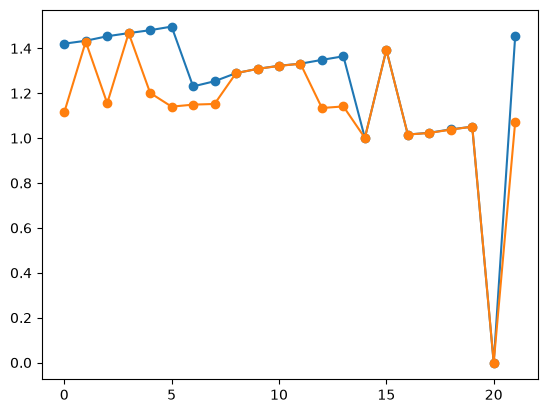

In [160]:
medium_resonances['resonance_freq_ch0'].plot(marker='o')
medium_resonances['resonance_freq_ch1'].plot(marker='o')
#plt.xlim(0, 19)

In [13]:
medium_resonances

,delta_L,resonance_freq_ch0,resonance_freq_ch1
0,0.0,1.420842,1.115230
1,1.0,1.433868,1.429860
2,2.0,1.453908,1.155311
3,3.0,1.467936,1.467936
4,4.0,1.480962,1.201403
5,5.0,1.496994,1.140281
6,6.0,1.230461,1.149299
7,7.0,1.253507,1.152305
8,8.0,1.289579,1.289579
9,8.5,1.308617,1.308617


In [27]:
solid_amplitudes_ch0 = pd.read_csv("C:/Users/dearb/Documents/UCD_labs/fourth_year_labs/acoustic_avoided_crossings/data/solid_amp_ch0_2.csv")
solid_amplitudes_ch1 = pd.read_csv("C:/Users/dearb/Documents/UCD_labs/fourth_year_labs/acoustic_avoided_crossings/data/solid_amp_ch1_2.csv")

small_amplitudes_ch0 = pd.read_csv("C:/Users/dearb/Documents/UCD_labs/fourth_year_labs/acoustic_avoided_crossings/data/small_amp_ch0_2.csv")
small_amplitudes_ch1 = pd.read_csv("C:/Users/dearb/Documents/UCD_labs/fourth_year_labs/acoustic_avoided_crossings/data/small_amp_ch1_2.csv")

medium_amplitudes_ch0 = pd.read_csv("C:/Users/dearb/Documents/UCD_labs/fourth_year_labs/acoustic_avoided_crossings/data/med_amp_ch0_2.csv")
medium_amplitudes_ch1 = pd.read_csv("C:/Users/dearb/Documents/UCD_labs/fourth_year_labs/acoustic_avoided_crossings/data/med_amp_ch1_2.csv")

big_amplitudes_ch0 = pd.read_csv("C:/Users/dearb/Documents/UCD_labs/fourth_year_labs/acoustic_avoided_crossings/data/big_amp_ch0_2.csv")
big_amplitudes_ch1 = pd.read_csv("C:/Users/dearb/Documents/UCD_labs/fourth_year_labs/acoustic_avoided_crossings/data/big_amp_ch1_2.csv")

In [33]:
solid_amplitudes_ch0 = solid_amplitudes_ch0.drop(labels = ['16', '17', '18', '19'], axis='columns')
solid_amplitudes_ch1 = solid_amplitudes_ch1.drop(labels = ['16', '17', '18', '19'], axis='columns')

small_amplitudes_ch0 = small_amplitudes_ch0.drop(labels = ['17', '18', '19'], axis='columns')
small_amplitudes_ch1 = small_amplitudes_ch1.drop(labels = ['17', '18', '19'], axis='columns')

medium_amplitudes_ch0 = medium_amplitudes_ch0.drop(labels = ['16', '17', '18', '19', '0.1', '499'], axis='columns')
medium_amplitudes_ch1 = medium_amplitudes_ch1.drop(labels = ['16', '17', '18', '19', '0.1', '499'], axis='columns')

big_amplitudes_ch0 = big_amplitudes_ch0.drop(labels = ['15', '16', '17', '18', '19'], axis='columns')
big_amplitudes_ch1 = big_amplitudes_ch1.drop(labels = ['15', '16', '17', '18', '19'], axis='columns')

Text(0, 0.5, 'Amplitude')

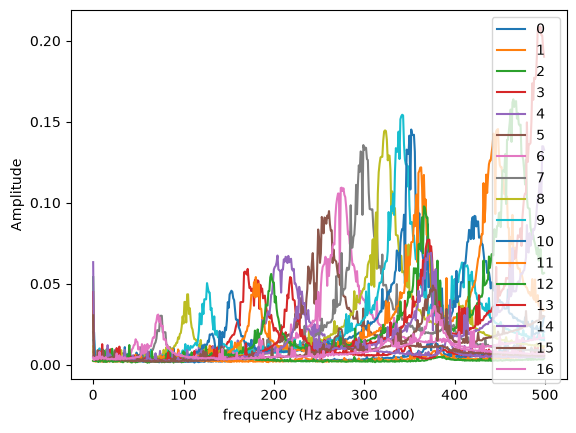

In [285]:
small_amplitudes_ch0.plot()
plt.xlabel('frequency (Hz above 1000)')
plt.ylabel('Amplitude')

In [249]:
small_amplitudes_ch0['7']

0      0.008938
1      0.004090
2      0.003761
3      0.003399
4      0.003666
         ...   
495    0.008744
496    0.008726
497    0.009144
498    0.009230
499    0.009156
Name: 7, Length: 500, dtype: float64

Text(0, 0.5, 'Amplitude')

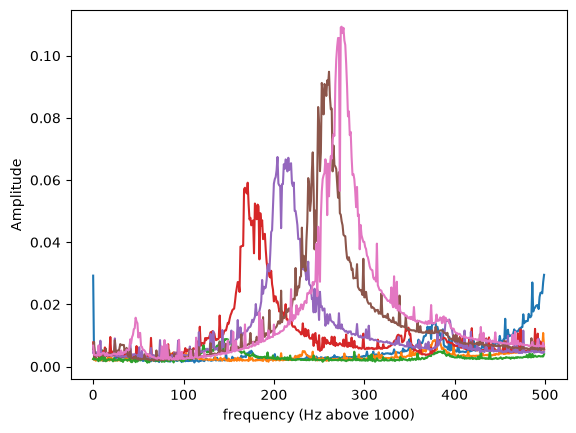

In [284]:
small_amplitudes_ch0['0'].plot()
small_amplitudes_ch0['1'].plot()
small_amplitudes_ch0['2'].plot()
small_amplitudes_ch0['3'].plot()
small_amplitudes_ch0['4'].plot()
small_amplitudes_ch0['5'].plot()
small_amplitudes_ch0['6'].plot()
# small_amplitudes_ch0['7'].plot()
# small_amplitudes_ch0['8'].plot()
# small_amplitudes_ch0['9'].plot()
# small_amplitudes_ch0['10'].plot()
plt.xlabel('frequency (Hz above 1000)')
plt.ylabel('Amplitude')

In [265]:
small_amplitudes_ch0['10'].iloc[200:500]

200    0.009504
201    0.008081
202    0.008170
203    0.008271
204    0.007729
         ...   
495    0.020905
496    0.020440
497    0.021675
498    0.020268
499    0.020447
Name: 10, Length: 300, dtype: float64

In [276]:
def get_peak_locs(data):
    data = data.iloc[200:500]
    filtered= savgol_filter(data, window_length = 45, polyorder=3)
    peaks, properties = find_peaks(filtered, prominence = 0.0005)
    return data.index[peaks[0]], data.index[peaks[1]], data.iloc[peaks[0]], data.iloc[peaks[1]]

In [277]:
p1_10, p2_10, f1_10, f2_10 = get_peak_locs(small_amplitudes_ch0['10'])

In [278]:
p1_9, p2_9, f1_9, f2_9 = get_peak_locs(small_amplitudes_ch0['9'])

In [279]:
p1_8, p2_8, f1_8, f2_8 = get_peak_locs(small_amplitudes_ch0['8'])

In [281]:
p1_7, p2_7, f1_7, f2_7 = get_peak_locs(small_amplitudes_ch0['7'])

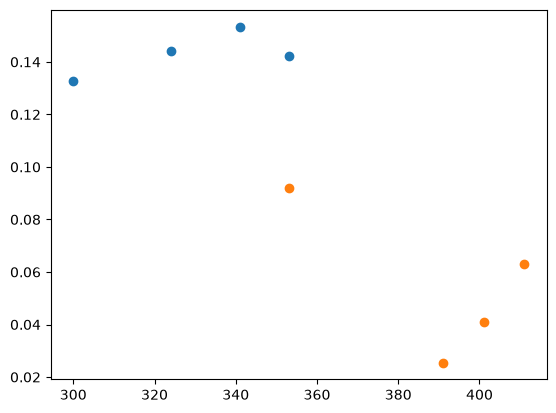

In [283]:
plt.scatter([p1_7, p1_8, p1_9, p1_10], [f1_7, f1_8, f1_9, f1_10])
plt.scatter([p2_7, p2_8, p2_9, p1_10], [f2_7, f2_8, f2_9, f2_10])

In [269]:
peaks

array([155, 246, 451])

In [270]:
p2_10

422

Text(0, 0.5, 'Amplitude')

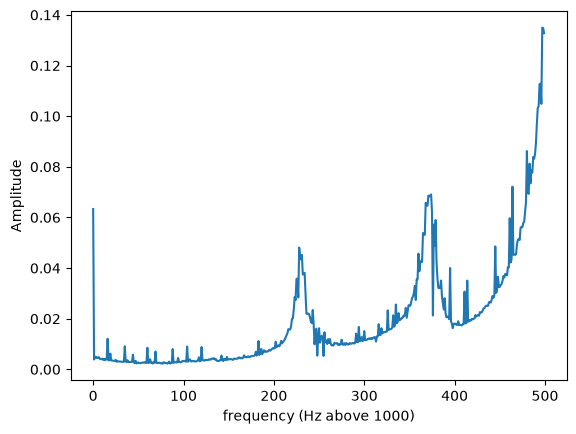

In [237]:
small_amplitudes_ch0['14'].plot()
plt.xlabel('frequency (Hz above 1000)')
plt.ylabel('Amplitude')

In [225]:
filtered_med_amp_1 = savgol_filter(medium_amplitudes_ch0['1'], window_length = 45, polyorder=3)
peaks, properties = find_peaks(filtered_med_amp_1, prominence = 0.0005)

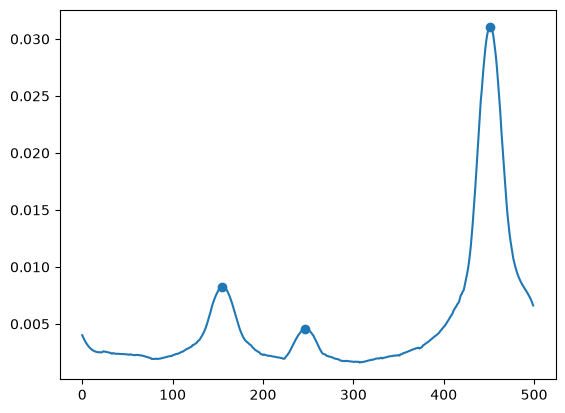

In [221]:
plt.plot(medium_amplitudes_ch0.index, filtered_med_amp_1)
plt.scatter(medium_amplitudes_ch0.index[peaks], filtered_med_amp_1[peaks])

Text(0, 0.5, 'Amplitude')

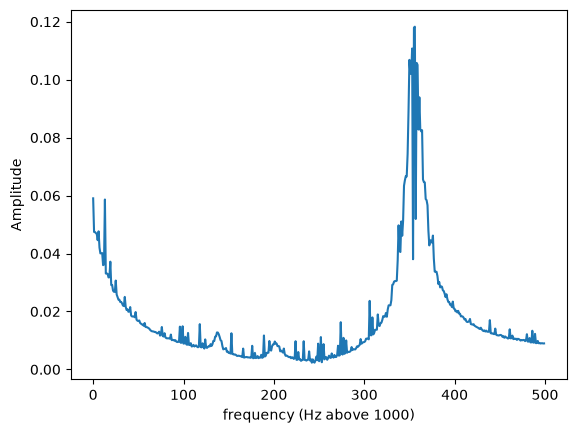

In [196]:
medium_amplitudes_ch0['10'].plot()
plt.xlabel('frequency (Hz above 1000)')
plt.ylabel('Amplitude')

Text(0, 0.5, 'Amplitude')

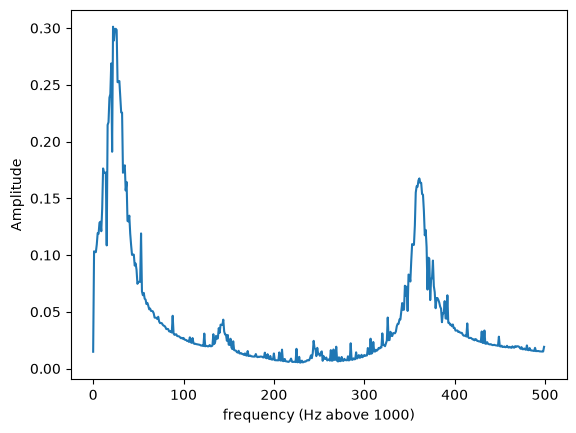

In [195]:
big_amplitudes_ch0['10'].plot()
plt.xlabel('frequency (Hz above 1000)')
plt.ylabel('Amplitude')

In [41]:
lab_solid_resonances = pd.read_csv("C:/Users/dearb/Documents/UCD_labs/fourth_year_labs/acoustic_avoided_crossings/data/solid_res_2.csv")

In [47]:
lab_solid_resonances 

,resonance_freq_ch0,resonance_freq_ch1
0,1.498998,1.293587
1,1.216433,1.289579
2,1.125251,1.292585
3,1.152305,1.292585
4,1.200401,1.289579
5,1.244489,1.292585
6,1.268537,1.293587
7,1.296593,1.291583
8,1.325651,1.293587
9,1.345691,1.291583


In [48]:
lab_solid_resonances = lab_solid_resonances.drop(labels = [16, 17, 18, 19], axis='rows')

In [71]:
lab_solid_resonances = lab_solid_resonances.set_index(pd.Index([0, 2, 4, 5, 6, 7, 7.5, 8, 8.5, 9, 9.5, 10, 10.5, 11, 11.5, 12.5]))

In [72]:

def lin(x, a, b):
    return a*x + b

popt, pcov = curve_fit(lin, lab_solid_resonances.index[2:-1], lab_solid_resonances['resonance_freq_ch0'].iloc[2:-1], p0=[-1, 1.5])
a_solid_res_ch0, b_solid_res_ch0 = popt
a_err_solid_res_ch0, b_err_solid_res_ch0 = np.sqrt(np.diag(pcov))

popt, pcov = curve_fit(lin, lab_solid_resonances.index, lab_solid_resonances['resonance_freq_ch1'])
a_solid_res_ch1, b_solid_res_ch1 = popt
a_err_solid_res_ch1, b_err_solid_res_ch1 = np.sqrt(np.diag(pcov))

x_int = (b_solid_res_ch0 - b_solid_res_ch1)/(a_solid_res_ch1 - a_solid_res_ch0)
y_int = lin(x_int, a_solid_res_ch0, b_solid_res_ch0)

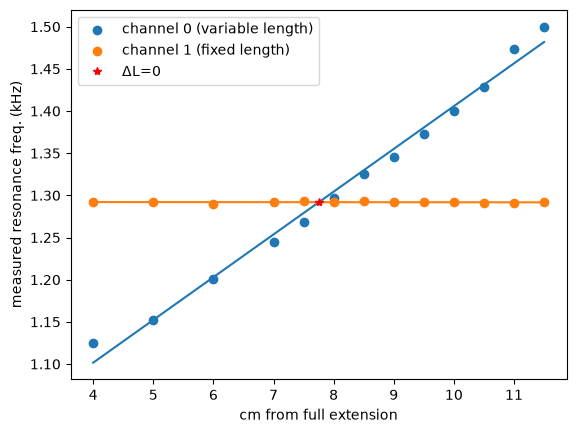

In [188]:
plt.scatter(lab_solid_resonances.index[2:-1], lab_solid_resonances['resonance_freq_ch0'].iloc[2:-1], label = 'channel 0 (variable length)')
plt.scatter(lab_solid_resonances.index[2:-1], lab_solid_resonances['resonance_freq_ch1'].iloc[2:-1], label = 'channel 1 (fixed length)')

plt.plot(lab_solid_resonances.index[2:-1], lin(lab_solid_resonances.index[2:-1], a_solid_res_ch0, b_solid_res_ch0))
plt.plot(lab_solid_resonances.index[2:-1], lin(lab_solid_resonances.index[2:-1], a_solid_res_ch1, b_solid_res_ch1))

plt.plot(x_int, y_int, marker='*', color='red', label='ΔL=0', linestyle='None')

plt.xlabel('cm from full extension')
plt.ylabel('measured resonance freq. (kHz)')
plt.legend()
#plt.xlim(3.5, 12.4)

In [80]:
x_int

np.float64(7.753887871825495)

In [82]:
solid_amplitudes_ch0

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,0.242310,0.027880,0.008538,0.005768,0.005568,0.003559,0.007007,0.003456,0.011973,0.014752,0.018725,0.025285,0.038312,0.003937,0.044868,0.020163
1,0.242360,0.004943,0.003600,0.004835,0.004924,0.003530,0.003450,0.003325,0.005685,0.004695,0.003656,0.003405,0.003655,0.003351,0.044663,0.003186
2,0.024357,0.005563,0.003481,0.002574,0.005298,0.003761,0.003493,0.003765,0.003693,0.003263,0.003171,0.003606,0.004143,0.003269,0.003673,0.003986
3,0.021773,0.005335,0.003395,0.003880,0.003835,0.003291,0.003365,0.003662,0.003587,0.004116,0.004018,0.003290,0.004144,0.003635,0.003310,0.004402
4,0.020589,0.005713,0.003728,0.002555,0.004559,0.003730,0.003209,0.003478,0.003551,0.004616,0.003369,0.003203,0.003846,0.004293,0.003624,0.003391
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.263083,0.026389,0.009687,0.005719,0.005337,0.005357,0.007146,0.009522,0.012653,0.015003,0.019995,0.026734,0.041747,0.113095,0.043407,0.020089
496,0.267749,0.026916,0.008674,0.005747,0.004452,0.005536,0.007079,0.010140,0.012448,0.014980,0.019726,0.026167,0.040009,0.106046,0.043550,0.019812
497,0.269423,0.026780,0.008886,0.005823,0.004379,0.005484,0.007052,0.009289,0.012353,0.015008,0.019701,0.030739,0.040048,0.106673,0.043695,0.020368
498,0.279449,0.042444,0.008570,0.005756,0.009794,0.005312,0.007026,0.009546,0.012221,0.016778,0.019171,0.025710,0.040039,0.106629,0.043227,0.020436


In [83]:
frequency_range = np.linspace(1, 1.5, 500)

In [91]:
(348/(0.25+(0.0775)))

1062.5954198473282

In [175]:
def step_size(n):
    if n<=2:
        return 2*n
    if n<=5:
        return 4 + n
    if n<=14:
        return 4 + 5 + 6*0.5
    else:
        return 4 + 5 + 3 + 1

In [182]:
solid_resonances_calc_ch0 = []
solid_resonances_calc_ch1 = []
for n in range(16):
    #calculating theoretical second harmonic resonance frequency with f=v/L, L=25+ΔL cm, ΔL=7.75-n cm
    if n!=0:
        res_th = np.round((343/(0.25+(0.0775-(step_size(n)/100))))-1000)
    else:
        res_th = np.round((343/(0.25+(0.0775)))-1000)
    #taking a region within +- 50 Hz of the theoretical resonance, and searching for measured peak in this region
    if int(res_th-50)<0:
        lower=0
    else:
        lower=int(res_th-50)
    if int(res_th+50)>500:
        upper=500
    else:
        upper=int(res_th+50)
    res_region = solid_amplitudes_ch0[str(n)].iloc[lower:upper]

    if res_region.empty:
        solid_resonances_calc_ch0.append(np.nan)
    else:
        max_pos = np.argmax(res_region.values)
        absolute_idx = res_region.index[max_pos]
        res_solid = frequency_range[absolute_idx]
            #res_loc = np.where(solid_amplitudes_ch0[str(n)]==np.max(res_region))
        #getting resonance from corresponding location in inputted frequency range
            #res_solid = frequency_range[res_loc]
        solid_resonances_calc_ch0.append(res_solid)

    #same for ch1:
    res_th = np.round((343/0.25)-1000)
    res_region = solid_amplitudes_ch1[str(n)].iloc[int(res_th-10):int(res_th+10)]
    max_pos = np.argmax(res_region.values)
    absolute_idx = res_region.index[max_pos]
    res_solid = frequency_range[absolute_idx]
    #res_loc = np.where(solid_amplitudes_ch1[str(n)]==np.max(res_region))
    #res_solid = frequency_range[res_loc]
    solid_resonances_calc_ch1.append(res_solid)


max_pos = np.argmax(res_region.values)

absolute_idx = res_region.index[max_pos]

res_solid = frequency_range[absolute_idx]
solid_resonances_calc_ch0.append(res_solid)

In [183]:
n

15

In [184]:
res_region.empty

False

In [185]:
#second harmonic only falls in this freq range for a portion of ΔLs - OOPS ahah
solid_resonances_calc_ch0
#why fewer values when I increase size of res_region ?????

[np.float64(1.001002004008016),
 np.float64(1.0731462925851702),
 np.float64(1.1482965931863727),
 np.float64(1.3406813627254508),
 np.float64(1.4228456913827654),
 np.float64(1.4358717434869739),
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 np.float64(1.3657314629258517)]

In [180]:
solid_resonances_calc_ch1

[np.float64(1.3807615230460921),
 np.float64(1.3687374749498997),
 np.float64(1.3647294589178356),
 np.float64(1.3817635270541082),
 np.float64(1.374749498997996),
 np.float64(1.374749498997996),
 np.float64(1.379759519038076),
 np.float64(1.3637274549098195),
 np.float64(1.374749498997996),
 np.float64(1.3647294589178356),
 np.float64(1.3727454909819639),
 np.float64(1.3807615230460921),
 np.float64(1.376753507014028),
 np.float64(1.3817635270541082),
 np.float64(1.3807615230460921),
 np.float64(1.3657314629258517)]

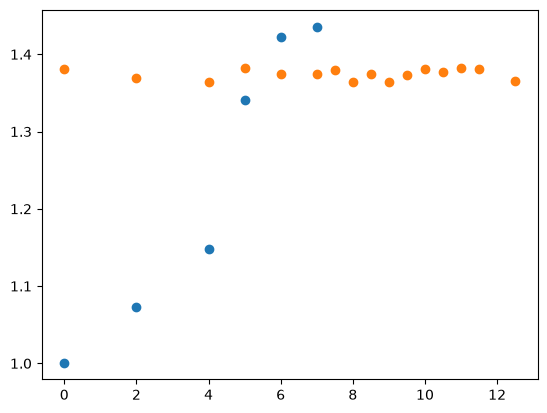

In [186]:
plt.scatter(lab_solid_resonances.index[:11], solid_resonances_calc_ch0[:11])
plt.scatter(lab_solid_resonances.index, solid_resonances_calc_ch1)